In [143]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [144]:
def explicit_fdm_hjb_solver(mu,r,sigma,T,
                            N,M,x_min,x_max,
                            gamma):
    
    h = (x_max-x_min)/N
    x = np.linspace(x_min,x_max,N+1)
    init_cond = (x**gamma-1)/gamma
    k = T/M
    V = np.zeros(shape=(M+1,N+1))
    V[0,:] = init_cond
    c = (mu - r)**2 / (2 * sigma**2)
    q_min = x_min / h
    q_max = x_max / h


    for m in range(M):
        for i in range(1,N):
            dx = (V[m, i + 1] - V[m, i - 1]) / (2 * h)
            dxx = (
                V[m, i + 1] - 2 * V[m, i] + V[m, i - 1]
            ) / h**2

            V[m + 1, i] = V[m, i] - k * (
                c * dx**2 / dxx
                - r * x[i] * dx
            )

        V[m + 1, 0] = (
            q_min * (4 * V[m + 1, 1] - V[m + 1, 2]) - 2
        ) / (3 * q_min + 2 * gamma)

        V[m + 1, -1] = (
            q_max * (4 * V[m + 1, -2] - V[m + 1, -3]) + 2
        ) / (3 * q_max - 2 * gamma)

    Vx = np.full_like(V, np.nan)
    Vxx = np.full_like(V, np.nan)

    Vx[:, 1:-1] = (
        V[:, 2:] - V[:, :-2]
    ) / (2 * h)

    Vxx[:, 1:-1] = (
        V[:, 2:] - 2 * V[:, 1:-1] + V[:, :-2]
    ) / h**2

    return V, Vx, Vxx


In [145]:
T=10
N=100
M=50000
sigma=0.2
r=0.01
mu=0.06
gamma = 0.5
x_min = 1
x_max = 20

x = np.linspace(x_min,x_max,N+1)


V,Vx,Vxx = explicit_fdm_hjb_solver(mu,r,sigma,T,N,M,x_min,x_max,gamma)
alpha = -(mu - r) / sigma**2 * Vx / (x[None, :] * Vxx)

In [146]:
tau = np.linspace(0, T, M + 1)

beta = gamma * (
    r + (mu - r)**2 / (2 * sigma**2 * (1 - gamma))
)

V_exact = (
    np.exp(beta * tau[:, None]) * x[None, :]**gamma - 1
) / gamma

In [147]:
alpha.shape

(50001, 101)

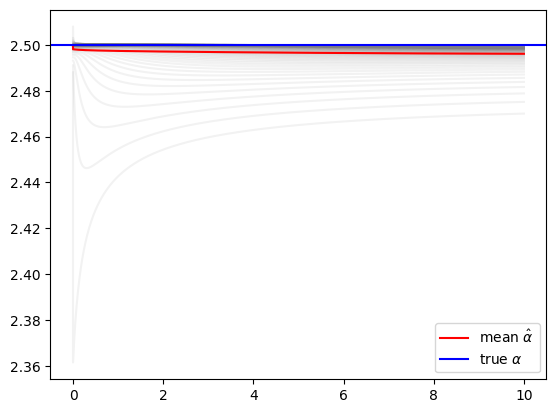

In [148]:
plt.plot(tau,alpha[:,1:-1],color="grey",alpha=0.1)
plt.plot(tau,np.mean(alpha[:,1:-1],axis=1),color="red",label=fr"mean $\hat{{\alpha}}$")

plt.axhline((mu-r)/((1-gamma)*sigma**2),color="blue",label=fr"true $\alpha$")
plt.legend()
plt.show()

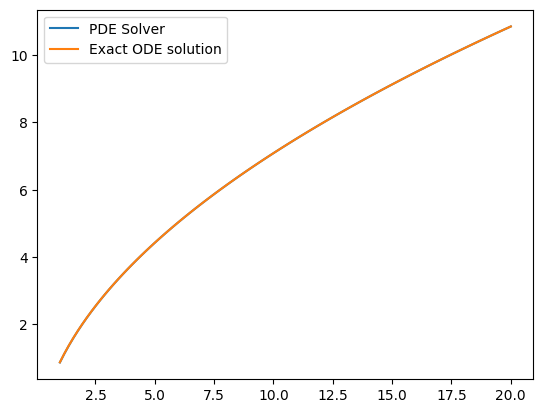

In [149]:
plt.plot(x,V[-1,:],label="PDE Solver")
plt.plot(x,V_exact[-1,:],label="Exact ODE solution")
plt.legend()
plt.show()

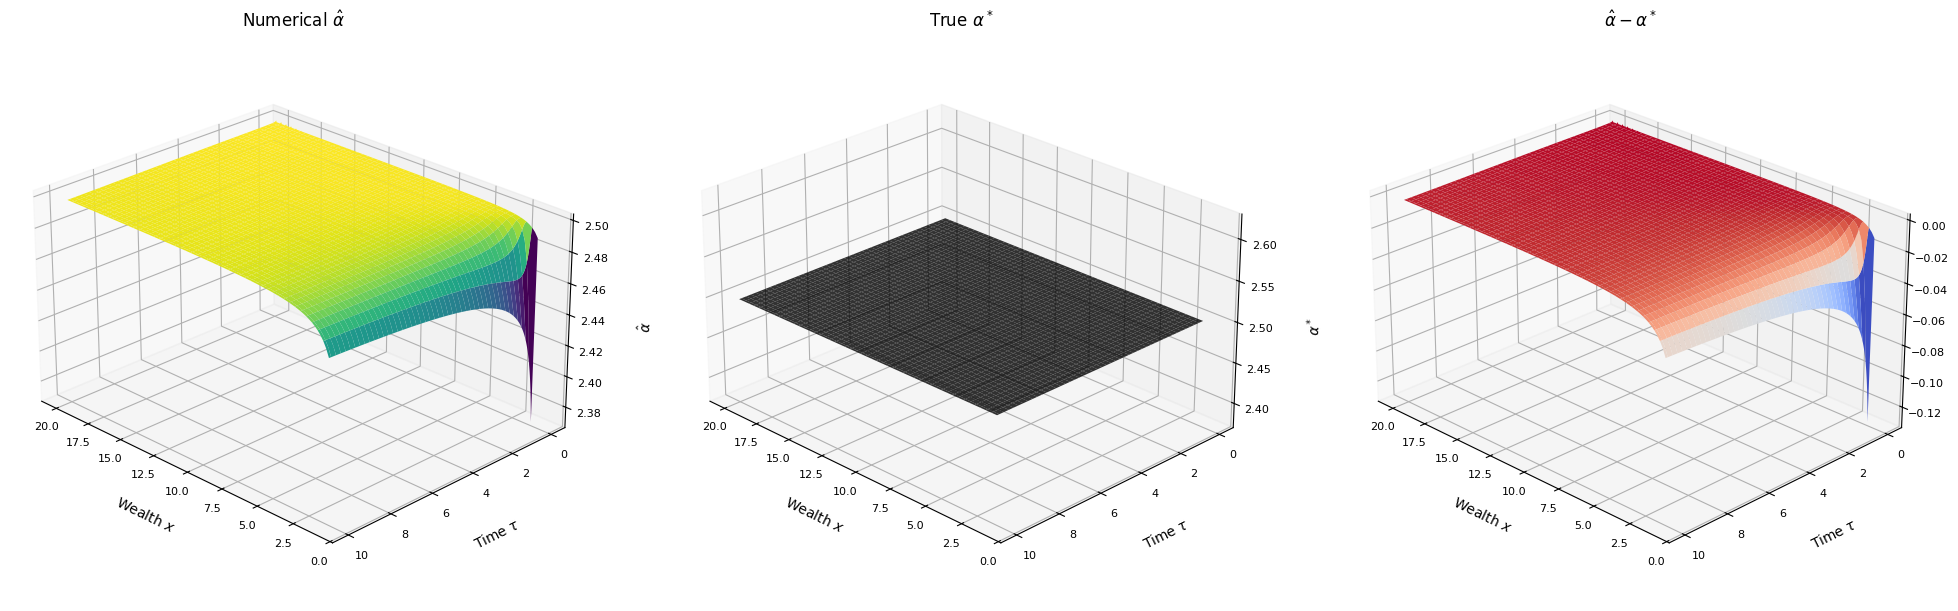

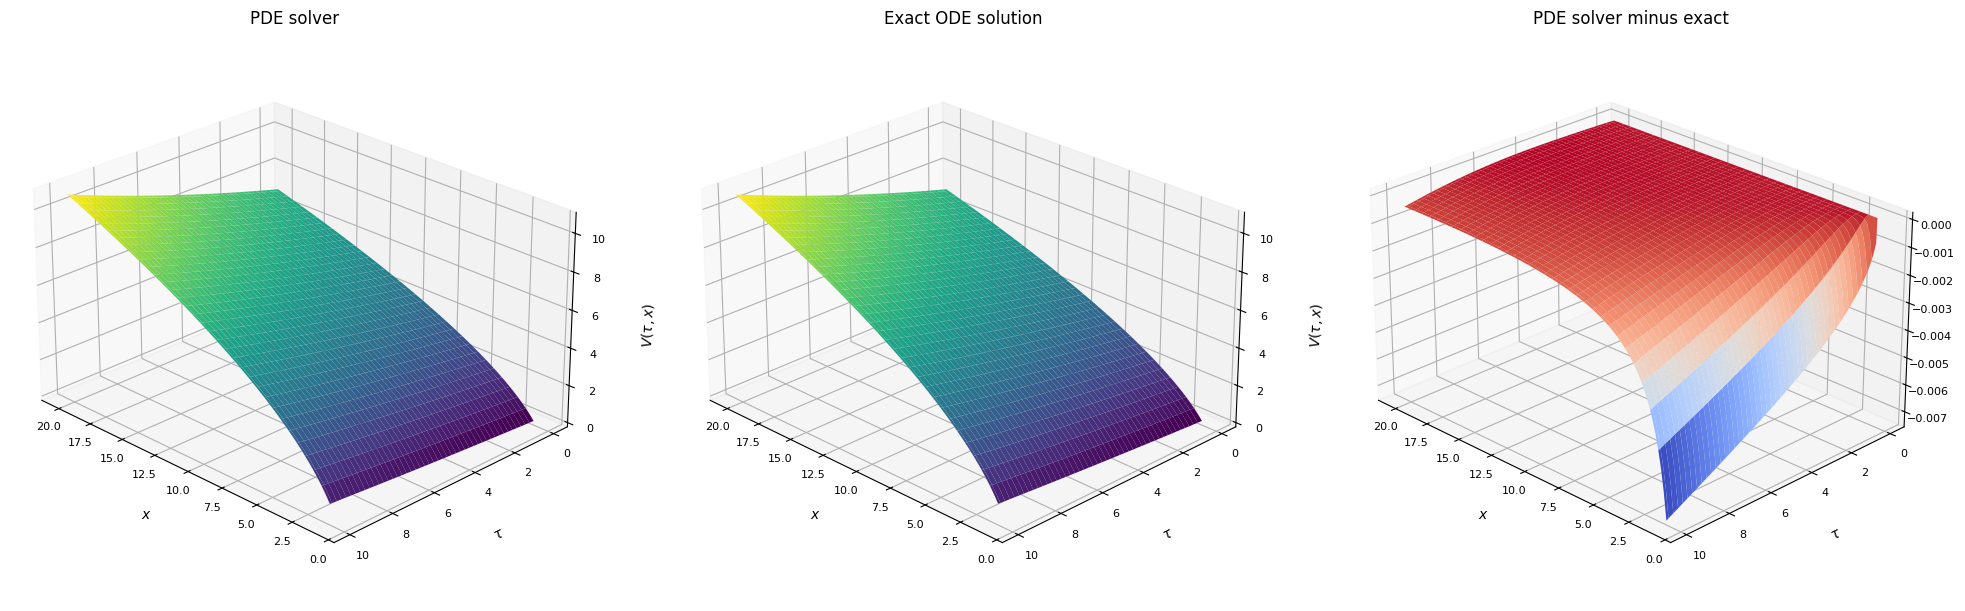

In [150]:
# Downsample time for faster rendering
step = max(1, len(tau) // 500)
ts = slice(None, None, step)

# Alpha surfaces and signed difference
X_alpha, Tau_alpha = np.meshgrid(x[1:-1], tau[ts])

alpha_true = (mu - r) / ((1 - gamma) * sigma**2)
alpha_exact = np.full_like(X_alpha, alpha_true)
alpha_difference = alpha[ts, 1:-1] - alpha_exact

fig = plt.figure(figsize=(20, 6), constrained_layout=True)

ax1 = fig.add_subplot(131, projection="3d")
ax1.plot_surface(
    X_alpha,
    Tau_alpha,
    alpha[ts, 1:-1],
    cmap="viridis",
    linewidth=0
)
ax1.set_title(r"Numerical $\hat{\alpha}$")

ax2 = fig.add_subplot(132, projection="3d")
ax2.plot_surface(
    X_alpha,
    Tau_alpha,
    alpha_exact,
    color="black",
    linewidth=0,
    alpha=0.8,
    shade=False
)
ax2.set_title(r"True $\alpha^*$")

ax3 = fig.add_subplot(133, projection="3d")
ax3.plot_surface(
    X_alpha,
    Tau_alpha,
    alpha_difference,
    cmap="coolwarm",
    linewidth=0
)
ax3.set_title(r"$\hat{\alpha}-\alpha^*$")

for axis, zlabel in zip(
    (ax1, ax2, ax3),
    (
        r"$\hat{\alpha}$",
        r"$\alpha^*$",
        r"$\hat{\alpha}-\alpha^*$"
    )
):
    axis.set_xlabel(r"Wealth $x$", labelpad=9)
    axis.set_ylabel(r"Time $\tau$", labelpad=9)
    axis.set_zlabel(zlabel, labelpad=9)
    axis.view_init(elev=25, azim=135)
    axis.set_box_aspect((1.25, 1.0, 0.7))
    axis.tick_params(labelsize=8, pad=1)

plt.show()


# Value-function surfaces and signed difference
X, Tau = np.meshgrid(x, tau[ts])
difference = V[ts, :] - V_exact[ts, :]

fig = plt.figure(figsize=(20, 6), constrained_layout=True)

ax1 = fig.add_subplot(131, projection="3d")
ax1.plot_surface(X, Tau, V[ts, :], cmap="viridis", linewidth=0)
ax1.set_title("PDE solver")

ax2 = fig.add_subplot(132, projection="3d")
ax2.plot_surface(X, Tau, V_exact[ts, :], cmap="viridis", linewidth=0)
ax2.set_title("Exact ODE solution")

ax3 = fig.add_subplot(133, projection="3d")
ax3.plot_surface(X, Tau, difference, cmap="coolwarm", linewidth=0)
ax3.set_title("PDE solver minus exact")

for axis, zlabel in zip(
    (ax1, ax2, ax3),
    (r"$V(\tau,x)$", r"$V(\tau,x)$", r"$V-V_{\mathrm{exact}}$")
):
    axis.set_xlabel(r"$x$", labelpad=9)
    axis.set_ylabel(r"$\tau$", labelpad=9)
    axis.set_zlabel(zlabel, labelpad=9)
    axis.view_init(elev=25, azim=135)
    axis.set_box_aspect((1.25, 1.0, 0.7))
    axis.tick_params(labelsize=8, pad=1)

plt.show()

In [164]:
import math
import torch
from torch import nn


def crra_utility(x, gamma):
    return (x.pow(gamma) - 1.0) / gamma


def rollout_wealth(
    model,
    z,
    mu,
    r,
    sigma,
    T,
    x0=1.0,
    return_paths=False,
):
    batch_size, n_steps = z.shape
    dt = T / n_steps
    sqrt_dt = math.sqrt(dt)

    if torch.is_tensor(x0):
        X = x0.to(
            device=z.device,
            dtype=z.dtype,
        ).reshape(-1)

        if X.numel() != batch_size:
            raise ValueError(
                "The number of initial wealth values "
                "must equal the batch size."
            )
    else:
        X = torch.full(
            (batch_size,),
            float(x0),
            dtype=z.dtype,
            device=z.device,
        )

    if return_paths:
        wealth_path = [X]
        alpha_path = []

    for n in range(n_steps):
        tau = torch.full_like(
            X,
            T - n * dt,
        )

        state = torch.stack(
            (tau, X),
            dim=1,
        )

        alpha = model(state).squeeze(-1)

        log_increment = (
            r
            + alpha * (mu - r)
            - 0.5 * alpha.square() * sigma**2
        ) * dt + alpha * sigma * sqrt_dt * z[:, n]

        X = X * torch.exp(log_increment)

        if return_paths:
            alpha_path.append(alpha)
            wealth_path.append(X)

    if return_paths:
        return (
            torch.stack(wealth_path, dim=1),
            torch.stack(alpha_path, dim=1),
        )

    return X


def train_policy(
    model,
    optimizer,
    mu,
    r,
    sigma,
    T,
    gamma,
    n_steps,
    epochs,
    batch_size,
    x0_grid,
    batches_per_epoch=1,
    n_val_paths=None,
    seed=0,
    print_every=25,
):
    model.double()

    device = next(model.parameters()).device
    dtype = torch.float64

    x0_grid = torch.as_tensor(
        x0_grid,
        dtype=dtype,
        device=device,
    ).reshape(-1)

    if batch_size != len(x0_grid):
        raise ValueError(
            "For a full grid batch, batch_size must equal "
            "len(x0_grid)."
        )

    torch.manual_seed(seed)

    if n_val_paths is None:
        n_val_paths = len(x0_grid)

    z_val = torch.randn(
        n_val_paths,
        n_steps,
        dtype=dtype,
        device=device,
    )

    x0_val = x0_grid.repeat(
        (n_val_paths + len(x0_grid) - 1)
        // len(x0_grid)
    )[:n_val_paths]

    history = {
        "train": [],
        "validation": [],
    }

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for _ in range(batches_per_epoch):
            z_train = torch.randn(
                batch_size,
                n_steps,
                dtype=dtype,
                device=device,
            )

            optimizer.zero_grad(set_to_none=True)

            terminal_wealth = rollout_wealth(
                model=model,
                z=z_train,
                mu=mu,
                r=r,
                sigma=sigma,
                T=T,
                x0=x0_grid,
            )

            loss = -crra_utility(
                terminal_wealth,
                gamma,
            ).mean()

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        train_loss = (
            total_train_loss / batches_per_epoch
        )
        history["train"].append(train_loss)

        model.eval()

        with torch.no_grad():
            terminal_wealth_val = rollout_wealth(
                model=model,
                z=z_val,
                mu=mu,
                r=r,
                sigma=sigma,
                T=T,
                x0=x0_val,
            )

            val_loss = -crra_utility(
                terminal_wealth_val,
                gamma,
            ).mean().item()

        history["validation"].append(val_loss)

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train {train_loss:.8f} | "
                f"validation {val_loss:.8f}"
            )

    return history

In [171]:
model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,16),
    nn.ReLU(),
    nn.Linear(16,1)
)

In [172]:
x0_grid = torch.linspace(
    0.5,
    4.0,
    101,
    dtype=torch.float64,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

history = train_policy(
    model=model,
    optimizer=optimizer,
    mu=mu,
    r=r,
    sigma=sigma,
    T=T,
    gamma=gamma,
    n_steps=100,
    epochs=200,
    batch_size=len(x0_grid),
    x0_grid=x0_grid,
    batches_per_epoch=20,
    print_every=25,
)

Epoch    0 | train -1.14027068 | validation -1.25204824
Epoch   25 | train -2.13128390 | validation -1.43954585
Epoch   50 | train -1.92710480 | validation -1.39625105
Epoch   75 | train -2.04624219 | validation -1.38327036
Epoch  100 | train -2.22322675 | validation -1.41364119
Epoch  125 | train -2.04809112 | validation -1.35171339
Epoch  150 | train -2.04124005 | validation -1.43200135
Epoch  175 | train -2.18752871 | validation -1.34954352


In [173]:
import numpy as np
import matplotlib.pyplot as plt
import torch


@torch.no_grad()
def evaluate_policy_surfaces(
    model,
    mu,
    r,
    sigma,
    T,
    gamma,
    n_steps,
    x_grid,
    tau_grid,
    n_mc=1_000,
    seed=1234,
):
    model.eval()

    device = next(model.parameters()).device
    dtype = torch.float64

    x_grid = torch.as_tensor(
        x_grid, dtype=dtype, device=device
    )
    tau_grid = torch.as_tensor(
        tau_grid, dtype=dtype, device=device
    )

    Tau, X = torch.meshgrid(
        tau_grid, x_grid, indexing="ij"
    )

    # Direct evaluation of the learned policy
    states = torch.stack((Tau, X), dim=-1)
    alpha_hat = model(states).squeeze(-1)

    # Monte Carlo estimate of the value under the learned policy
    V_hat = torch.empty_like(Tau)

    torch.manual_seed(seed)

    for j, tau_tensor in enumerate(tau_grid):
        tau0 = float(tau_tensor)

        if tau0 == 0.0:
            V_hat[j] = crra_utility(x_grid, gamma)
            continue

        # Preserve approximately the training time-step size
        remaining_steps = max(
            1, round(n_steps * tau0 / T)
        )

        dt = tau0 / remaining_steps
        sqrt_dt = np.sqrt(dt)

        # One MC sample collection for every initial wealth
        wealth = x_grid[:, None].expand(
            -1, n_mc
        ).clone()

        for n in range(remaining_steps):
            remaining_time = tau0 - n * dt
            tau_input = torch.full_like(
                wealth, remaining_time
            )

            state = torch.stack(
                (tau_input, wealth), dim=-1
            )

            alpha = model(state).squeeze(-1)

            # Common random numbers across initial wealth values
            z = torch.randn(
                1,
                n_mc,
                dtype=dtype,
                device=device,
            )

            log_increment = (
                r
                + alpha * (mu - r)
                - 0.5 * alpha.square() * sigma**2
            ) * dt + alpha * sigma * sqrt_dt * z

            wealth = wealth * torch.exp(log_increment)

        V_hat[j] = crra_utility(
            wealth, gamma
        ).mean(dim=1)

    # Theoretical Merton solution
    alpha_star = (
        (mu - r) / ((1.0 - gamma) * sigma**2)
    )

    growth_rate = gamma * (
        r
        + (mu - r)**2
        / (2.0 * (1.0 - gamma) * sigma**2)
    )

    V_exact = (
        X.pow(gamma) * torch.exp(growth_rate * Tau)
        - 1.0
    ) / gamma

    alpha_exact = torch.full_like(
        alpha_hat, alpha_star
    )

    return {
        "X": X.cpu().numpy(),
        "Tau": Tau.cpu().numpy(),
        "alpha_hat": alpha_hat.cpu().numpy(),
        "alpha_exact": alpha_exact.cpu().numpy(),
        "V_hat": V_hat.cpu().numpy(),
        "V_exact": V_exact.cpu().numpy(),
    }

In [174]:
x_plot = np.linspace(x.min(), x.max(), 40)
tau_plot = np.linspace(0.0, T, 30)

results = evaluate_policy_surfaces(
    model=model,
    mu=mu,
    r=r,
    sigma=sigma,
    T=T,
    gamma=gamma,
    n_steps=100,
    x_grid=x_plot,
    tau_grid=tau_plot,
    n_mc=1_000,
)

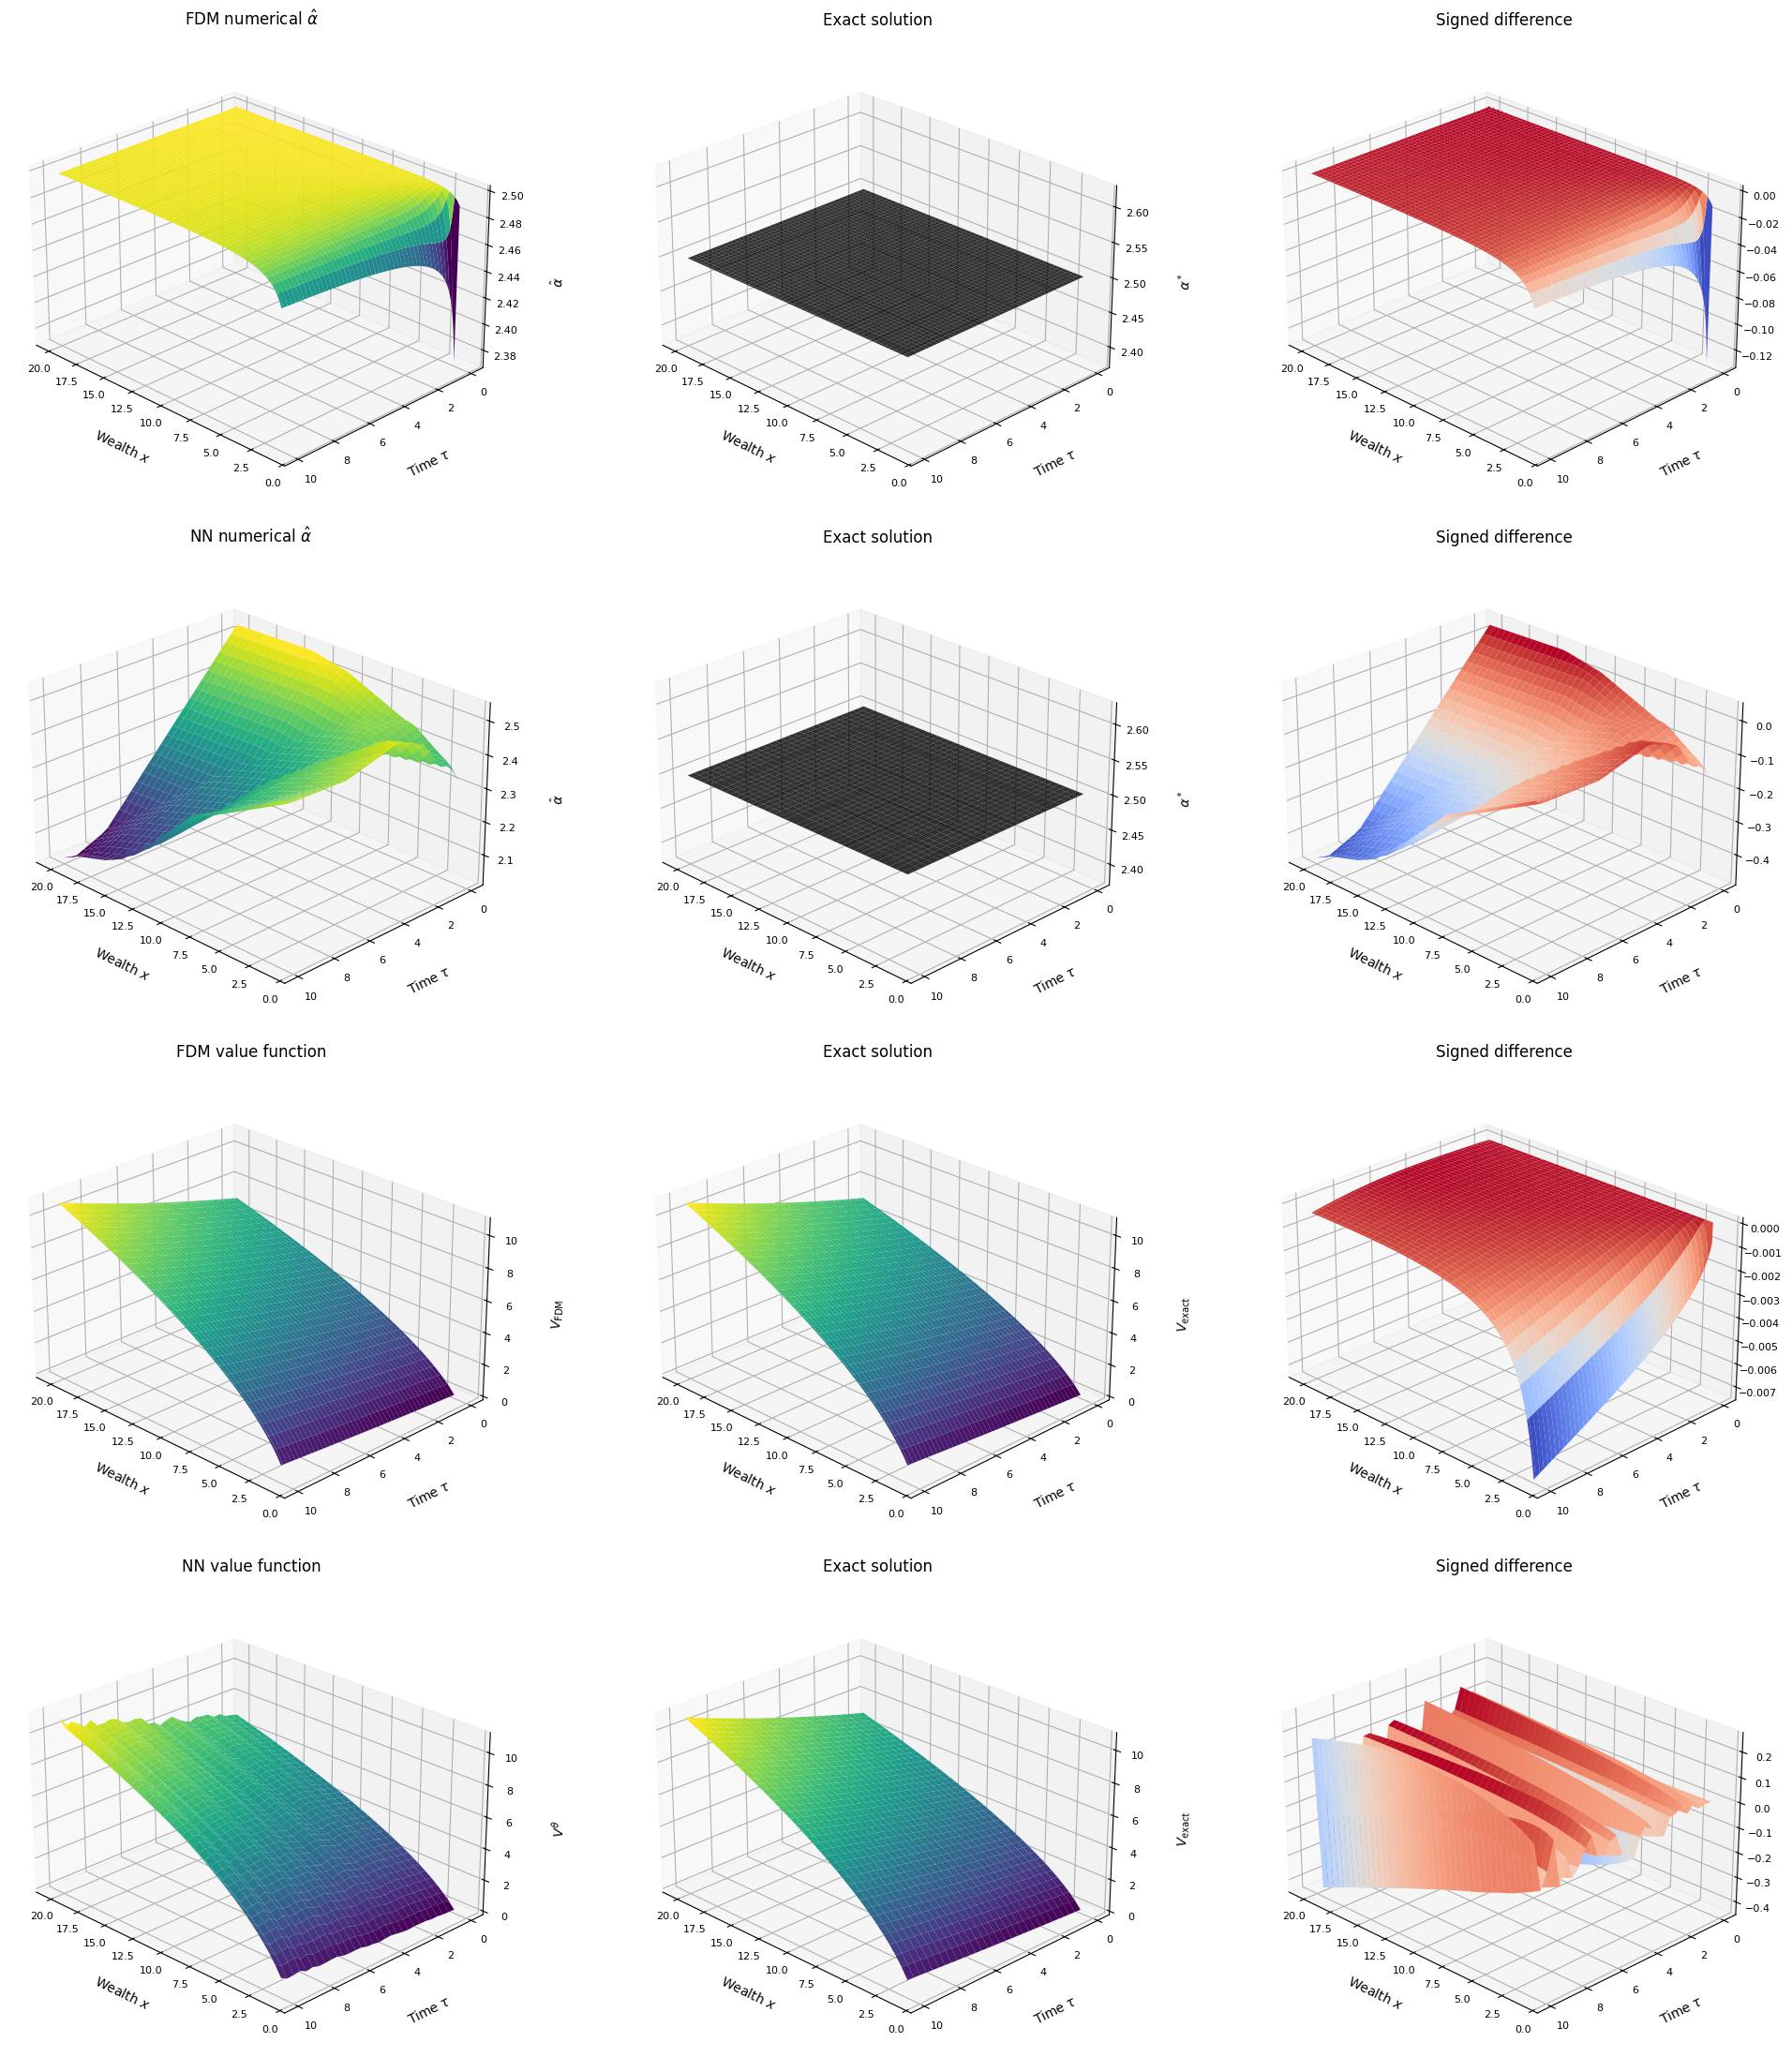

In [175]:
# ------------------------------------------------------------
# FDM surfaces
# ------------------------------------------------------------

step = max(1, len(tau) // 500)
ts = slice(None, None, step)

X_alpha_fdm, Tau_alpha_fdm = np.meshgrid(
    x[1:-1], tau[ts]
)

alpha_true = (
    (mu - r) / ((1 - gamma) * sigma**2)
)

alpha_exact_fdm = np.full_like(
    X_alpha_fdm,
    alpha_true,
)

alpha_difference_fdm = (
    alpha[ts, 1:-1] - alpha_exact_fdm
)

X_fdm, Tau_fdm = np.meshgrid(
    x, tau[ts]
)

V_difference_fdm = (
    V[ts, :] - V_exact[ts, :]
)

# ------------------------------------------------------------
# Neural-network surfaces
# ------------------------------------------------------------

X_nn = results["X"]
Tau_nn = results["Tau"]

alpha_hat_nn = results["alpha_hat"]
alpha_exact_nn = results["alpha_exact"]

alpha_difference_nn = (
    alpha_hat_nn - alpha_exact_nn
)

V_hat_nn = results["V_hat"]
V_exact_nn = results["V_exact"]

V_difference_nn = (
    V_hat_nn - V_exact_nn
)

# ------------------------------------------------------------
# Combined 4 x 3 plot
# ------------------------------------------------------------

rows = [
    {
        "title": r"FDM numerical $\hat{\alpha}$",
        "X": X_alpha_fdm,
        "Tau": Tau_alpha_fdm,
        "numerical": alpha[ts, 1:-1],
        "exact": alpha_exact_fdm,
        "difference": alpha_difference_fdm,
        "zlabels": (
            r"$\hat{\alpha}$",
            r"$\alpha^*$",
            r"$\hat{\alpha}-\alpha^*$",
        ),
        "is_alpha": True,
    },
    {
        "title": r"NN numerical $\hat{\alpha}$",
        "X": X_nn,
        "Tau": Tau_nn,
        "numerical": alpha_hat_nn,
        "exact": alpha_exact_nn,
        "difference": alpha_difference_nn,
        "zlabels": (
            r"$\hat{\alpha}$",
            r"$\alpha^*$",
            r"$\hat{\alpha}-\alpha^*$",
        ),
        "is_alpha": True,
    },
    {
        "title": "FDM value function",
        "X": X_fdm,
        "Tau": Tau_fdm,
        "numerical": V[ts, :],
        "exact": V_exact[ts, :],
        "difference": V_difference_fdm,
        "zlabels": (
            r"$V_{\mathrm{FDM}}$",
            r"$V_{\mathrm{exact}}$",
            r"$V_{\mathrm{FDM}}-V_{\mathrm{exact}}$",
        ),
        "is_alpha": False,
    },
    {
        "title": "NN value function",
        "X": X_nn,
        "Tau": Tau_nn,
        "numerical": V_hat_nn,
        "exact": V_exact_nn,
        "difference": V_difference_nn,
        "zlabels": (
            r"$V^\theta$",
            r"$V_{\mathrm{exact}}$",
            r"$V^\theta-V_{\mathrm{exact}}$",
        ),
        "is_alpha": False,
    },
]

fig = plt.figure(
    figsize=(20, 22),
    constrained_layout=True,
)

for row_index, row in enumerate(rows):
    surfaces = [
        row["numerical"],
        row["exact"],
        row["difference"],
    ]

    for col_index, Z in enumerate(surfaces):
        ax = fig.add_subplot(
            4,
            3,
            row_index * 3 + col_index + 1,
            projection="3d",
        )

        if col_index == 1 and row["is_alpha"]:
            ax.plot_surface(
                row["X"],
                row["Tau"],
                Z,
                color="black",
                linewidth=0,
                alpha=0.8,
                shade=False,
            )
        else:
            cmap = (
                "coolwarm"
                if col_index == 2
                else "viridis"
            )

            ax.plot_surface(
                row["X"],
                row["Tau"],
                Z,
                cmap=cmap,
                linewidth=0,
            )

        if col_index == 0:
            ax.set_title(row["title"])
        elif col_index == 1:
            ax.set_title("Exact solution")
        else:
            ax.set_title("Signed difference")

        ax.set_xlabel(
            r"Wealth $x$",
            labelpad=9,
        )
        ax.set_ylabel(
            r"Time $\tau$",
            labelpad=9,
        )
        ax.set_zlabel(
            row["zlabels"][col_index],
            labelpad=9,
        )

        ax.view_init(
            elev=25,
            azim=135,
        )

        ax.set_box_aspect(
            (1.25, 1.0, 0.7)
        )

        ax.tick_params(
            labelsize=8,
            pad=1,
        )

plt.show()